In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/MachineLearning/heart.csv')

print('Dataset berhasil diload!')
print('Shape:', df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset berhasil diload!
Shape: (1025, 14)


In [4]:
df = pd.read_csv('/content/drive/MyDrive/MachineLearning/heart.csv')

print('Shape dataset:', df.shape)
print('\nInfo dataset:')
print(df.info())
print('\n5 baris pertama:')
df.head()

Shape dataset: (1025, 14)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print('Missing Values:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())
print('\nJumlah duplikat:', df.duplicated().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

Jumlah duplikat: 723


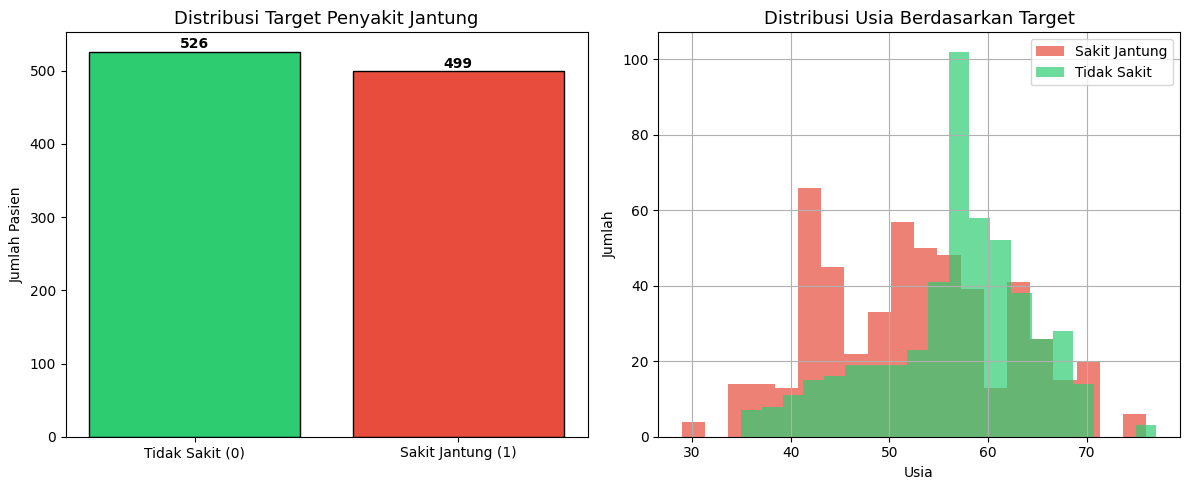

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['target'].value_counts()
axes[0].bar(['Tidak Sakit (0)', 'Sakit Jantung (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Target Penyakit Jantung', fontsize=13)
axes[0].set_ylabel('Jumlah Pasien')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

df[df['target']==1]['age'].hist(ax=axes[1], alpha=0.7, color='#e74c3c', label='Sakit Jantung', bins=20)
df[df['target']==0]['age'].hist(ax=axes[1], alpha=0.7, color='#2ecc71', label='Tidak Sakit', bins=20)
axes[1].set_title('Distribusi Usia Berdasarkan Target', fontsize=13)
axes[1].set_xlabel('Usia')
axes[1].set_ylabel('Jumlah')
axes[1].legend()

plt.tight_layout()
plt.show()

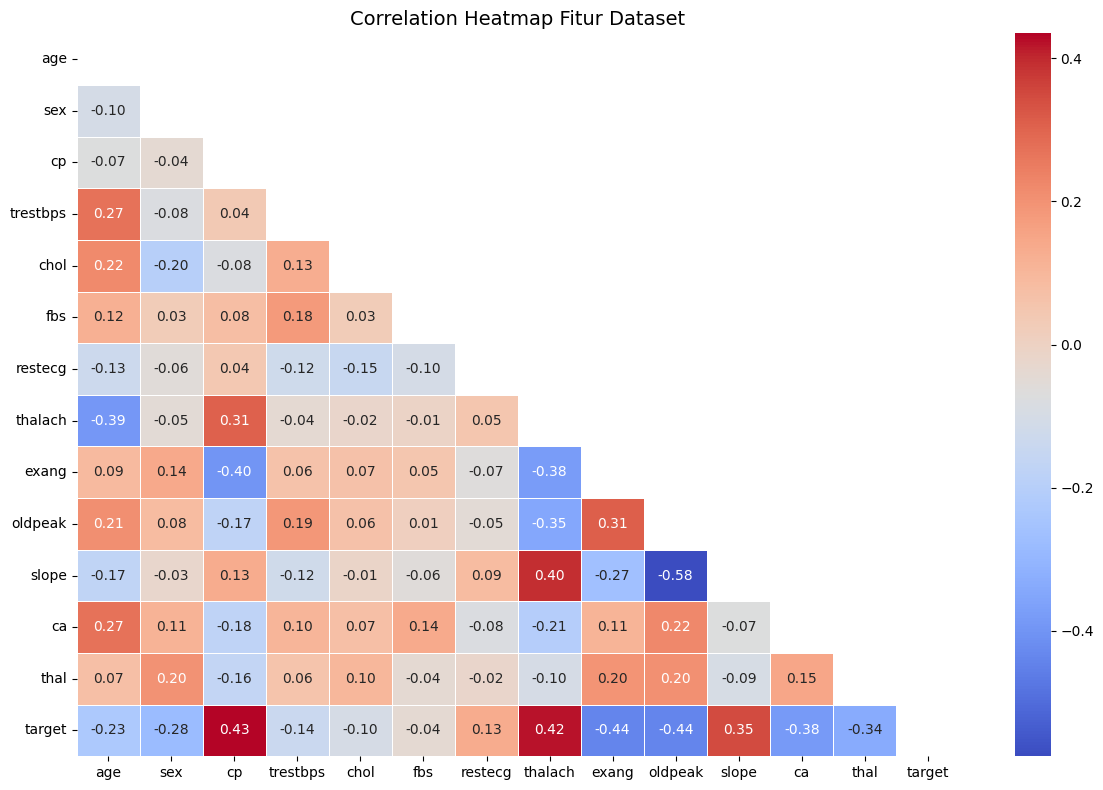

In [8]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5)
plt.title('Correlation Heatmap Fitur Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Hapus duplikat & missing values
df_clean = df.drop_duplicates().dropna()
print('Shape setelah cleaning:', df_clean.shape)

# Pisah fitur dan target
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# ✅ FIXED: Split DULU sebelum standardisasi (mencegah data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ FIXED: Scaler hanya di-fit pada data training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform pada training
X_test_scaled = scaler.transform(X_test)         # transform saja pada testing

print('Data training:', X_train_scaled.shape)
print('Data testing:', X_test_scaled.shape)


In [10]:
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train_scaled, y_train)

print('Model berhasil dilatih!')


In [11]:
from sklearn.metrics import roc_curve

# Prediksi probabilitas
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Threshold Default ---
y_pred_default = model.predict(X_test_scaled)
acc_default = accuracy_score(y_test, y_pred_default)
print(f'=== Threshold Default (0.50) ===')
print(f'Akurasi: {acc_default*100:.2f}%')
print(classification_report(y_test, y_pred_default, target_names=['Tidak Sakit', 'Sakit Jantung']))

# --- Threshold Optimal (prioritas Recall untuk konteks medis) ---
# Dalam prediksi penyakit, False Negative lebih berbahaya dari False Positive
# Sehingga threshold diturunkan agar model lebih sensitif mendeteksi risiko
THRESHOLD = 0.40
y_pred_opt = (y_proba >= THRESHOLD).astype(int)
acc_opt = accuracy_score(y_test, y_pred_opt)
print(f'=== Threshold Konservatif ({THRESHOLD}) ===')
print(f'Akurasi: {acc_opt*100:.2f}%')
print(classification_report(y_test, y_pred_opt, target_names=['Tidak Sakit', 'Sakit Jantung']))


In [12]:
cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Sakit', 'Sakit Jantung'],
            yticklabels=['Tidak Sakit', 'Sakit Jantung'])
plt.title('Confusion Matrix - Random Forest (Threshold 0.40)', fontsize=13)
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()


In [13]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance - Random Forest', fontsize=13)
plt.xlabel('Tingkat Kepentingan')
plt.tight_layout()
plt.show()


In [14]:
# Simpan model, scaler, dan threshold
with open('model_rf.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# ✅ BARU: Simpan threshold agar konsisten dengan Streamlit
with open('threshold.pkl', 'wb') as f:
    pickle.dump(THRESHOLD, f)

print('Model, scaler, dan threshold disimpan!')
print('Files: model_rf.pkl, scaler.pkl, threshold.pkl')
